# 2.6
# Решение алгебраических и трансцендентных уравнений с помощью инструментальных средств
# В папке Instrumental находится файл с функциями или можно открыть по ссылке:
https://smath.info/ru-RU/cloud/sheet/kgoSshFPyH

## Упражнение №1:
### Найти методом половинного деления корень трансцендентного уравнения lg x - cos x = 0 с четырьмя знаками после запятой

In [8]:
from numpy import *
import matplotlib.pyplot as plt
from tabulate import tabulate

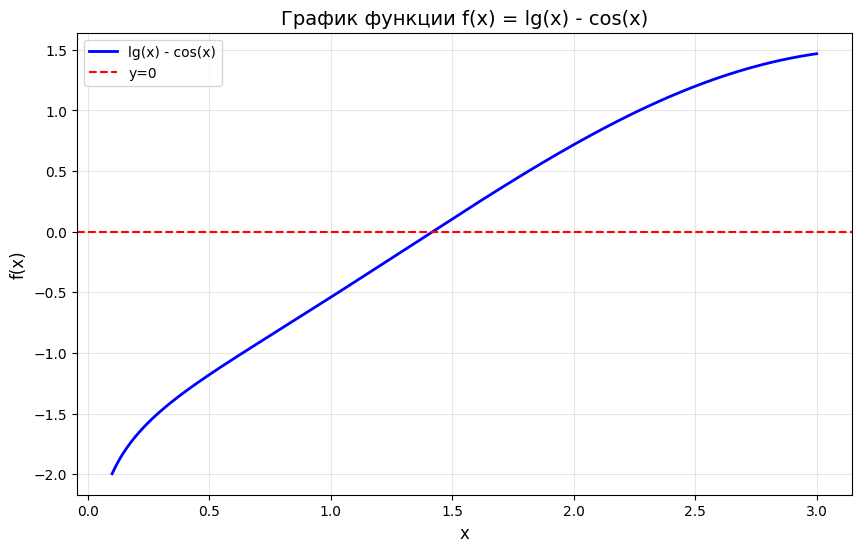

Приближенное значение корня: 1.4184


In [9]:
# Определение функции
def equation(x):
    return log10(x) - cos(x)

# Построение графика
x_vals = linspace(0.1, 3, 500)
y_vals = equation(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, 'b-', linewidth=2, label='lg(x) - cos(x)')
plt.axhline(0, color='r', linestyle='--', label='y=0')
plt.grid(True, alpha=0.3)
plt.title('График функции f(x) = lg(x) - cos(x)', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend()
plt.show()

# Нахождение корня методом бисекции
left_bound, right_bound = 1.3, 1.5  # интервал из графика
tolerance = 1e-5
max_iterations = 30

for iteration in range(max_iterations):
    midpoint = (left_bound + right_bound) / 2
    
    if equation(left_bound) * equation(midpoint) < 0:
        right_bound = midpoint
    else:
        left_bound = midpoint
    
    if (right_bound - left_bound) < tolerance:
        break

print(f"Приближенное значение корня: {midpoint:.4f}")

### Скриншот из инструментального пакета
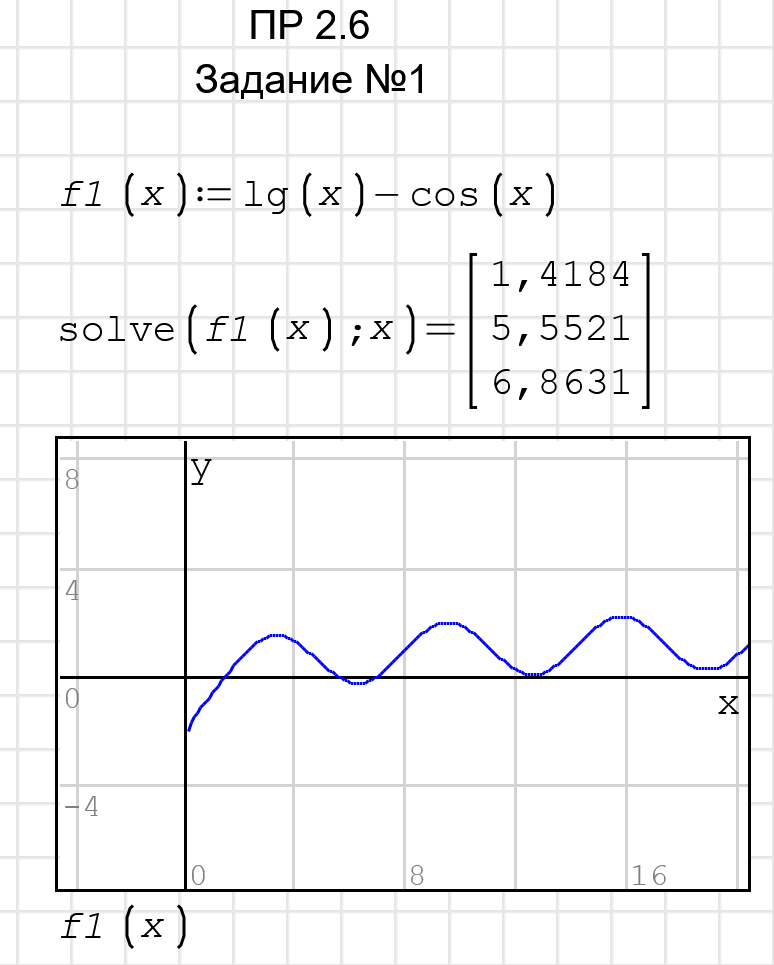

## Упражнение №2:
### Отделите графически корни уравнения x^2 - 3,2x = 1. Найти одним из итерационных методов действительный корень данного уравнения с точностью 10^-4

Точные корни квадратного уравнения: 3.486796 и -0.286796


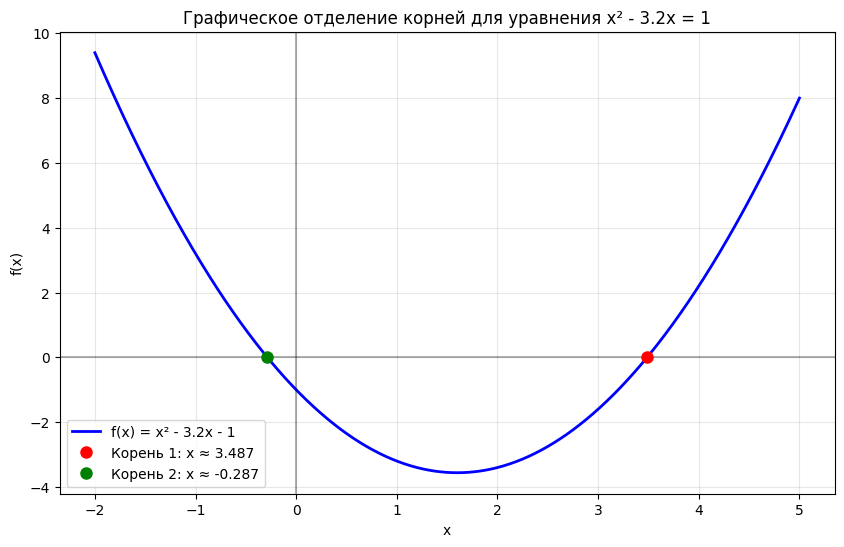

+------------+---------+---------+---------------+
|   Итерация |       x |   x_new |   |x_new - x| |
+============+=========+=========+===============+
|          1 | 3.5     | 3.49285 |      0.00715  |
+------------+---------+---------+---------------+
|          2 | 3.49285 | 3.48957 |      0.003277 |
+------------+---------+---------+---------------+
|          3 | 3.48957 | 3.48807 |      0.001503 |
+------------+---------+---------+---------------+
|          4 | 3.48807 | 3.48738 |      0.000689 |
+------------+---------+---------+---------------+
|          5 | 3.48738 | 3.48706 |      0.000316 |
+------------+---------+---------+---------------+
|          6 | 3.48706 | 3.48692 |      0.000145 |
+------------+---------+---------+---------------+
|          7 | 3.48692 | 3.48685 |      6.7e-05  |
+------------+---------+---------+---------------+
Достигнута требуемая точность 10^-4

РЕЗУЛЬТАТ: x = 3.486853


In [14]:
def f2(x):
    return x**2 - 3.2 * x - 1

x_vals2 = linspace(-2, 5, 1000)
y_vals2 = f2(x_vals2)

# Строим график
plt.figure(figsize=(10, 6))
plt.plot(x_vals2, y_vals2, 'b-', linewidth=2, label='f(x) = x² - 3.2x - 1')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Графическое отделение корней для уравнения x² - 3.2x = 1')
plt.legend()

# Точное решение при помощи numpy
roots2 = roots([1, -3.2, -1])
print(f"Точные корни квадратного уравнения: {roots2[0]:.6f} и {roots2[1]:.6f}")

# Отмечаем корни на графике
plt.plot(roots2[0], 0, 'ro', markersize=8, label=f'Корень 1: x ≈ {roots2[0]:.3f}')
plt.plot(roots2[1], 0, 'go', markersize=8, label=f'Корень 2: x ≈ {roots2[1]:.3f}')
plt.legend()
plt.show()

def g2(x):
    """Итерационная функция для положительного корня"""
    return sqrt(3.2*x + 1)

x = 3.5 # Начальное приближение

table_data = []

iteration = 1
while True:
    x_new = g2(x) 
    error = abs(x_new - x)
    
    table_data.append([iteration, f"{x:.6f}", f"{x_new:.6f}", f"{error:.6f}"])
    
    if error < 0.0001: # Достигнута точность
        break
    
    x = x_new
    iteration += 1

# Выводим таблицу
headers = ["Итерация", "x", "x_new", "|x_new - x|"]
print(tabulate(table_data, headers=headers, tablefmt="grid"))
print(f"Достигнута требуемая точность 10^-4")

root2 = x_new
print(f"\nРЕЗУЛЬТАТ: x = {root2:.6f}")

### Скриншот из инструментального пакета
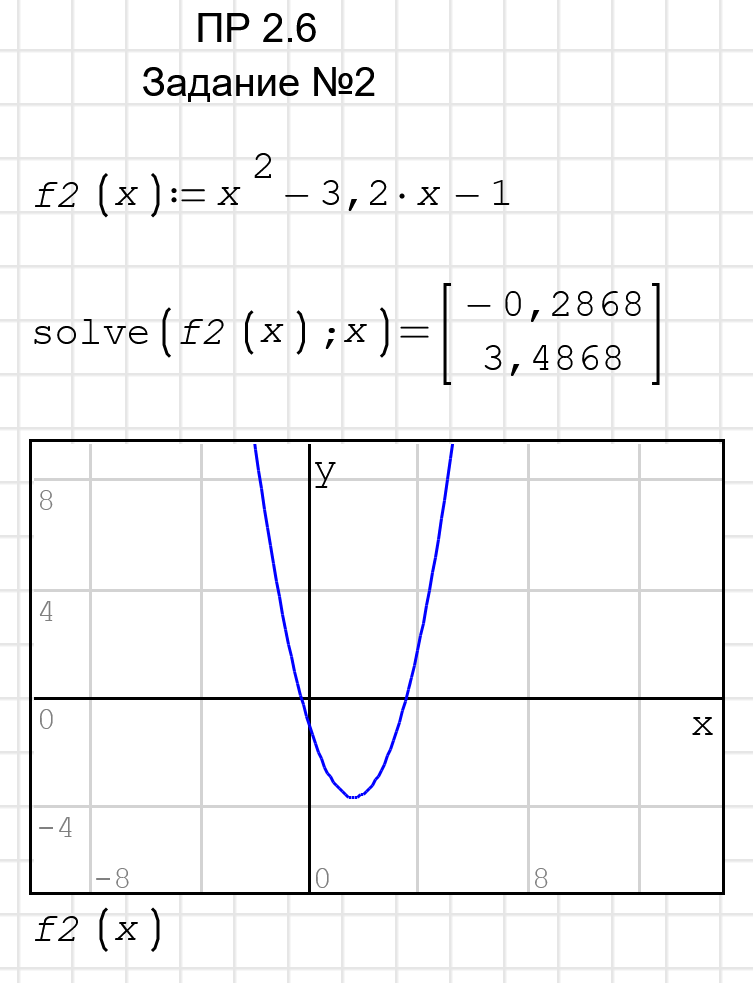

## Упражнение №3:
### Найти наибольший положительный корень уравнения 4x - 3 ln x = 4 с точностью 10^-4

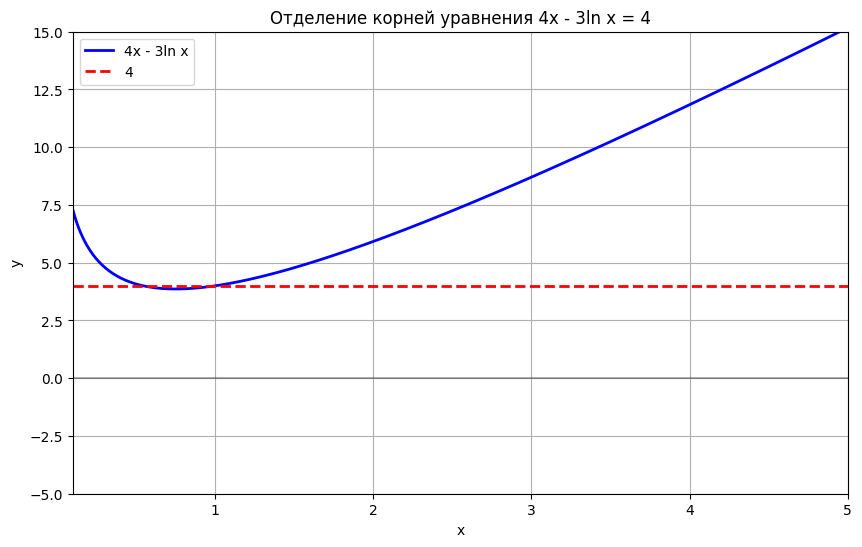

Корень на отрезке [0.54; 0.55]
Корень на отрезке [0.99; 1.00]
+------------+----------+-----------+----------+---------------+
|   Итерация |        x |      f(x) |   phi(x) |   |x_new - x| |
+============+==========+===========+==========+===============+
|          1 | 0.995    | -0.004962 | 0.995496 |      0.000496 |
+------------+----------+-----------+----------+---------------+
|          2 | 0.995496 | -0.004473 | 0.995944 |      0.000447 |
+------------+----------+-----------+----------+---------------+
|          3 | 0.995944 | -0.004032 | 0.996347 |      0.000403 |
+------------+----------+-----------+----------+---------------+
|          4 | 0.996347 | -0.003633 | 0.99671  |      0.000363 |
+------------+----------+-----------+----------+---------------+
|          5 | 0.99671  | -0.003274 | 0.997037 |      0.000327 |
+------------+----------+-----------+----------+---------------+
|          6 | 0.997037 | -0.002949 | 0.997332 |      0.000295 |
+------------+----------+---

In [12]:
x = linspace(0.1, 5, 500)

# Строим график для отделения корней
y1 = 4 * x - 3 * log(x)
y2 = 4 * ones_like(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y1, label='4x - 3ln x', color='blue', linewidth=2)
plt.plot(x, y2, label='4', color='red', linewidth=2, linestyle='--')
plt.grid(True)
plt.legend()
plt.title('Отделение корней уравнения 4x - 3ln x = 4')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0.1, 5)
plt.ylim(-5, 15)
plt.show()

# Находим отрезки, где функция меняет знак
for i in range(len(x)-1):
    diff_current = y1[i] - y2[i]
    diff_next = y1[i+1] - y2[i+1]
    
    if diff_current * diff_next < 0: # Смена знака -> есть корень
        print(f"Корень на отрезке [{x[i]:.2f}; {x[i+1]:.2f}]")

def f(x):
    return 4*x - 3*log(x) - 4

lam = -0.1 

def phi(x):
    """Итерационная функция: x = x + lam * f(x)"""
    return x + lam * f(x)

x0 = 0.995 # Начальное значение
eps = 0.0001 # Точность

table_data = []

x = x0
n = 0

while True:
    x_new = phi(x)
    error = abs(x_new - x)
    f_val = f(x)
    
    table_data.append([n+1, f"{x:.6f}", f"{f_val:.6f}", f"{x_new:.6f}", f"{error:.6f}"])
    
    if error < eps:
        x = x_new
        break
    
    x = x_new
    n += 1

# Выводим результаты
headers = ["Итерация", "x", "f(x)", "phi(x)", "|x_new - x|"]
print(tabulate(table_data, headers=headers, tablefmt="grid"))

print(f"Наибольший положительный корень на отрезке [0.99, 1.00]:")
print(f"x = {x:.6f}")

### Скриншот из инструментального пакета
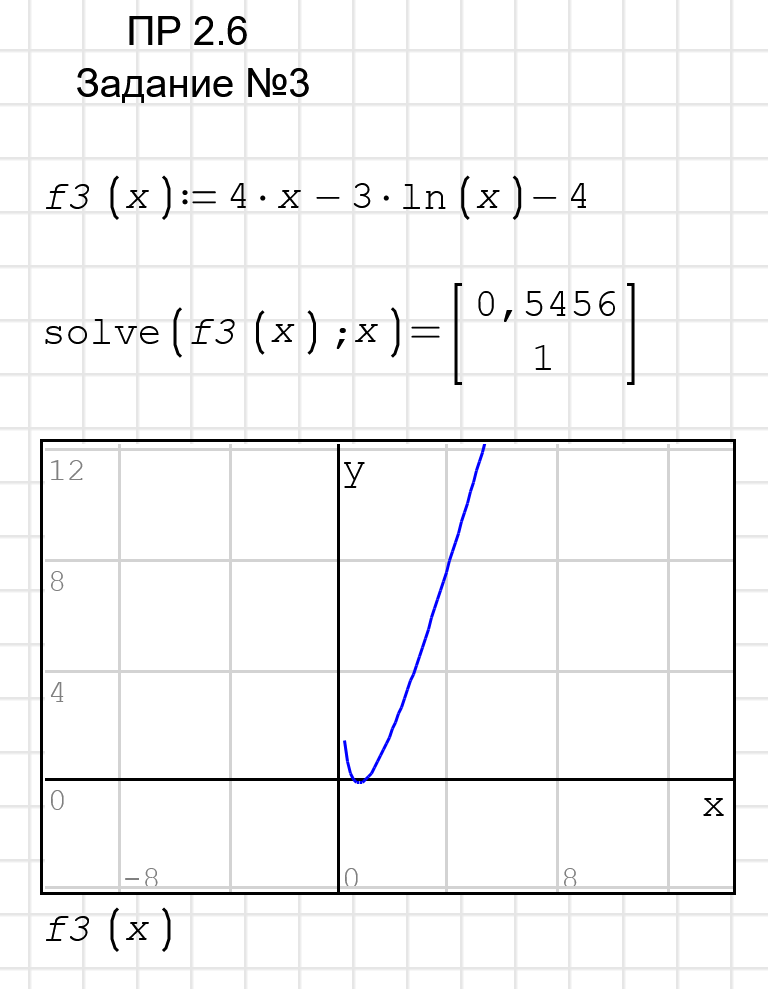